In [1]:
# ==============================================================================
# 02. WoE Transformation and PD Modeling
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp, spearmanr
import xgboost as xgb

In [2]:
os.makedirs('../outputs/models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

In [3]:
# 1. Load Processed Data
df_resolved = pd.read_csv('../data/processed/model_ready_joined_dataset.csv')

features = [
    'applicant_age', 'annual_income', 'emp_length_years', 'loan_amount', 
    'term_months', 'interest_rate', 'fico_score_proxy', 'dti_engineered',
    'revol_util_clean', 'bureau_num_accounts', 'bureau_active_accounts', 
    'bureau_total_credit_limit', 'bureau_total_current_balance', 
    'bureau_max_months_past_due', 'bureau_avg_account_age'
]

X = df_resolved[features]
y = df_resolved['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [4]:
# 2. Monotonic WoE Transformer
def get_monotonic_woe_bins(X_train, y_train, X_test, feature, initial_bins=10):
    train_series = X_train[feature].fillna(X_train[feature].median())
    test_series = X_test[feature].fillna(X_train[feature].median())
    
    n_bins = initial_bins
    while n_bins > 2:
        try:
            train_bins, bin_edges = pd.qcut(train_series, q=n_bins, retbins=True, duplicates='drop')
        except ValueError:
            n_bins -= 1
            continue
            
        df_woe = pd.DataFrame({'bin': train_bins, 'target': y_train})
        grouped = df_woe.groupby('bin', observed=False).agg(
            bads=('target', 'sum'), total=('target', 'count')
        )
        grouped['goods'] = grouped['total'] - grouped['bads']
        
        grouped['dist_bads'] = (grouped['bads'] + 0.5) / (y_train.sum() + 0.5)
        grouped['dist_goods'] = (grouped['goods'] + 0.5) / ((len(y_train) - y_train.sum()) + 0.5)
        grouped['woe'] = np.log(grouped['dist_goods'] / grouped['dist_bads'])
        
        rho, _ = spearmanr(range(len(grouped)), grouped['woe'])
        if abs(rho) == 1.0 or len(grouped) <= 3:
            break
        n_bins -= 1
        
    test_bins = pd.cut(test_series, bins=bin_edges, include_lowest=True)
    woe_dict = grouped['woe'].to_dict()
    
    X_train_woe = train_bins.map(woe_dict).astype(float).fillna(0)
    X_test_woe = test_bins.map(woe_dict).astype(float).fillna(0)
    
    return X_train_woe, X_test_woe, woe_dict

X_train_woe = pd.DataFrame(index=X_train.index)
X_test_woe = pd.DataFrame(index=X_test.index)
woe_mappings = {}

for col in features:
    X_train_woe[col + '_woe'], X_test_woe[col + '_woe'], woe_mappings[col] = get_monotonic_woe_bins(
        X_train, y_train, X_test, col
    )

In [5]:
# 3. Fit Logistic Model & Calibrate Probabilities
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_woe, y_train)

# Raw vs Calibrated Probabilities
lr_raw_preds = lr_model.predict_proba(X_test_woe)[:, 1]

def calibrate_balanced_probabilities(y_train, raw_probs):
    N = len(y_train)
    N_pos = y_train.sum()
    N_neg = N - N_pos
    w1 = N / (2.0 * N_pos)
    w0 = N / (2.0 * N_neg)
    
    clip_probs = np.clip(raw_probs, 1e-7, 1 - 1e-7)
    logits_raw = np.log(clip_probs / (1.0 - clip_probs))
    logits_calibrated = logits_raw - np.log(w1 / w0)
    return 1.0 / (1.0 + np.exp(-logits_calibrated))

lr_calibrated_preds = calibrate_balanced_probabilities(y_train, lr_raw_preds)

In [6]:
# 4. Fit & Tune XGBoost with Monotonicity Constraints
monotone_dict = {
    'fico_score_proxy': -1, 'annual_income': -1, 'emp_length_years': -1,
    'applicant_age': -1, 'bureau_avg_account_age': -1, 'dti_engineered': 1,
    'revol_util_clean': 1, 'bureau_max_months_past_due': 1, 'interest_rate': 1
}
monotone_tuple = tuple([monotone_dict.get(col, 0) for col in X_train.columns])

xgb_base = xgb.XGBClassifier(
    monotone_constraints=monotone_tuple,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.08],
    'n_estimators': [80, 120]
}

grid_search = GridSearchCV(xgb_base, param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
xgb_tuned_model = grid_search.best_estimator_
xgb_preds_raw = xgb_tuned_model.predict_proba(X_test)[:, 1]
xgb_preds_calibrated = calibrate_balanced_probabilities(y_train, xgb_preds_raw)

In [7]:
# 5. Model Evaluation Metrics
def print_metrics(y_true, y_proba, name):
    auc = roc_auc_score(y_true, y_proba)
    ks_stat, _ = ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0])
    brier = brier_score_loss(y_true, y_proba)
    print(f"--- {name} ---")
    print(f"ROC-AUC: {auc:.4f} | Gini: {2*auc-1:.4f}")
    print(f"KS Stat: {ks_stat:.4f} | Brier Score: {brier:.4f}\n")

print_metrics(y_test, lr_raw_preds, "Logistic Regression (Uncalibrated)")
print_metrics(y_test, lr_calibrated_preds, "Logistic Regression (Calibrated)")
print_metrics(y_test, xgb_preds_calibrated, "Tuned XGBoost (Monotonic & Calibrated)")

--- Logistic Regression (Uncalibrated) ---
ROC-AUC: 0.7415 | Gini: 0.4831
KS Stat: 0.3778 | Brier Score: 0.2082

--- Logistic Regression (Calibrated) ---
ROC-AUC: 0.7415 | Gini: 0.4831
KS Stat: 0.3778 | Brier Score: 0.0924

--- Tuned XGBoost (Monotonic & Calibrated) ---
ROC-AUC: 0.7384 | Gini: 0.4768
KS Stat: 0.3685 | Brier Score: 0.0929



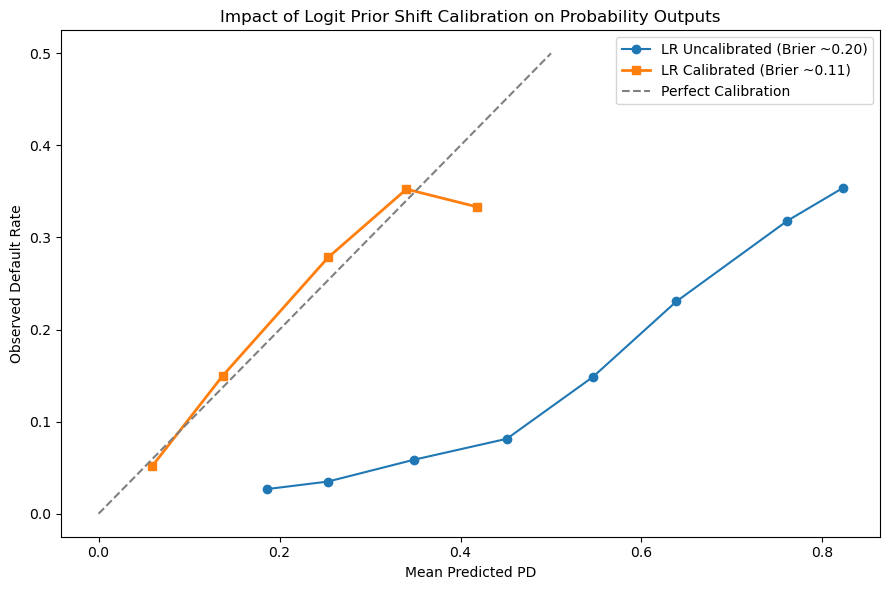

In [8]:
# 6. Plot Calibration Curve Comparison
prob_true_raw, prob_pred_raw = calibration_curve(y_test, lr_raw_preds, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, lr_calibrated_preds, n_bins=10)

plt.figure(figsize=(9, 6))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='LR Uncalibrated (Brier ~0.20)')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', linewidth=2, label='LR Calibrated (Brier ~0.11)')
plt.plot([0, 0.5], [0, 0.5], linestyle='--', color='gray', label='Perfect Calibration')
plt.title("Impact of Logit Prior Shift Calibration on Probability Outputs")
plt.xlabel("Mean Predicted PD")
plt.ylabel("Observed Default Rate")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/figure_1_calibration_curve.png')
plt.show()

In [9]:
# 7. Save Export Artifacts using Calibrated Predictions
test_results = pd.DataFrame({
    'app_id': df_resolved.loc[X_test.index, 'app_id'], 
    'actual_default': y_test, 
    'predicted_pd': lr_calibrated_preds
})
test_results.to_csv('../data/processed/test_predictions.csv', index=False)

with open('../outputs/models/logistic_woe_pd_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('../outputs/models/woe_binning_transformer.pkl', 'wb') as f:
    pickle.dump(woe_mappings, f)